# » `Dependencias`:

In [ ]:
# !pip install plotly
# %pip install sqlalchemy
# %pip install numpy
# %pip install matplotlib

In [1]:
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import re
import matplotlib.pyplot as plt
# import cufflinks as cf
# from IPython.display import display, HTML

# cf.set_config_file

## 1. Conección → SIM(172.27.0.124)

In [2]:
# spring.datasource.url = jdbc:sqlserver://172.27.250.27;databaseName=SIRIM
SERVER = '172.27.0.124' # '172.27.0.242'
#DRIVER = 'SQL Server Native Client 11.0'
DRIVER = 'ODBC Driver 17 for SQL Server'
DATABASE = 'SIM'
USERNAME = 'userestadistica' # 'udesa'
PASSWORD = '$Us3R_3sT4d1sTic4$' # 'DESARROLLO2006'
DATABASE_CONNECTION = f'mssql://{USERNAME}:{PASSWORD}@{SERVER}/{DATABASE}?driver={DRIVER}'

engine = create_engine(DATABASE_CONNECTION)
connection = engine.connect()

## 2. Métodos genérico:

In [3]:
def get_query_sql(query):
    df = pd.read_sql(query, connection)
    return df

## 3. Visualización de datos: `INF-ENE2025`

### 3.1 Se define como regla de calidad que los países sin límites marítimos no podrán realizar movimientos migratorios de entradas o salidas a través de via transporte marítimo.

In [29]:
df_1 = pd.read_excel('./data/A1.xlsx')

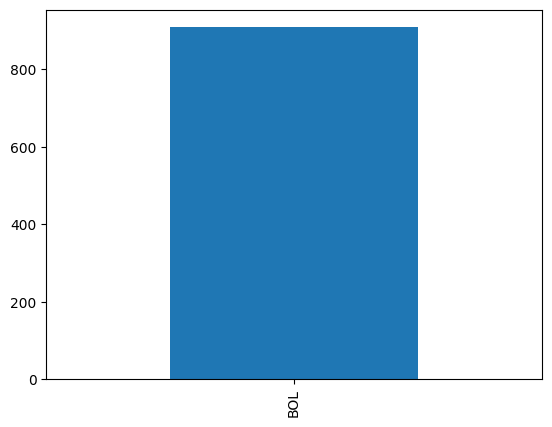

In [41]:
# ['Tipo Movimiento', 'Fecha Control', 'Via Transporte', 'Pais Movimiento', 'Dependencia']

df_1_f = df_1.groupby(by=['Pais Movimiento']).agg({ 'Id Persona': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_1_f = df_1_f.plot.bar(legend=False, xlabel='')


### 3.2. Se define como regla de calidad que los países asociados al continente europeo no deberán registrar movimientos migratorios a través del transporte terrestre.

In [42]:
df_2 = pd.read_excel('./data/A2.xlsx')

<Axes: >

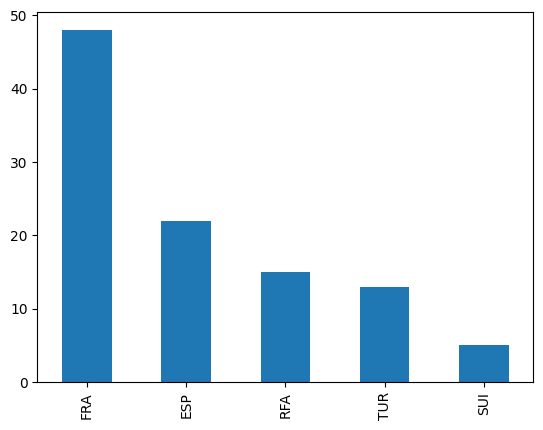

In [44]:
# ['Tipo Movimiento', 'Fecha Control', 'Via Transporte', 'Pais Movimiento', 'Dependencia']

df_2_f = df_2.groupby(by=['Pais Movimiento']).agg({ 'Id Persona': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_2_f.plot.bar(legend=False, xlabel='')

### 3.3 Se define como regla que, la fecha programada del itinerario debe ser coherente y no debe exceder significativamente la fecha actual.

In [24]:
df_3 = pd.read_excel('./data/A3.xlsx')

<Axes: >

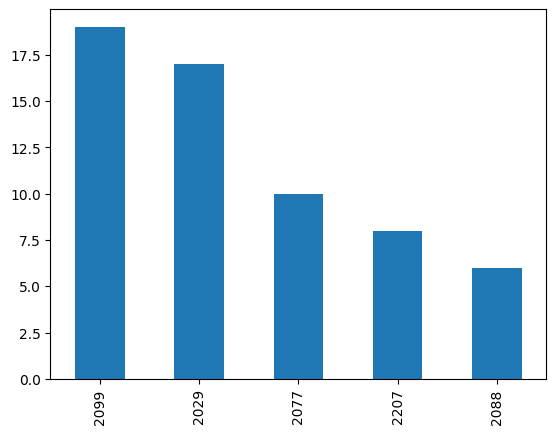

In [28]:
# ['Id Itinerario', 'Fecha Programada', 'Estado', 'Tipo Movimiento', 'Cantidad Movimiento']

df_3['Fecha Programada'] = pd.to_datetime(df_3['Fecha Programada'], errors='coerce')
df_3['nAño'] = df_3['Fecha Programada'].dt.year.fillna(0).astype(int)

df_3_f = df_3[df_3['nAño'] > 2025]
df_3_f = df_3_f.groupby(by=['nAño']).agg({ 'Id Itinerario': [np.ma.count] }) \
               .droplevel(level=0, axis=1) \
               .sort_values(by='count', ascending=False) \
               .head(5)

df_3_f.plot.bar(legend=False, xlabel='')



### 3.4 Se define como regla, que los trámites que otorguen una calidad migratoria deben actualizar dicha calidad en los datos generales.

In [15]:
# Extracción
df_4 = pd.read_excel('./data/A4.xlsx')

<Axes: >

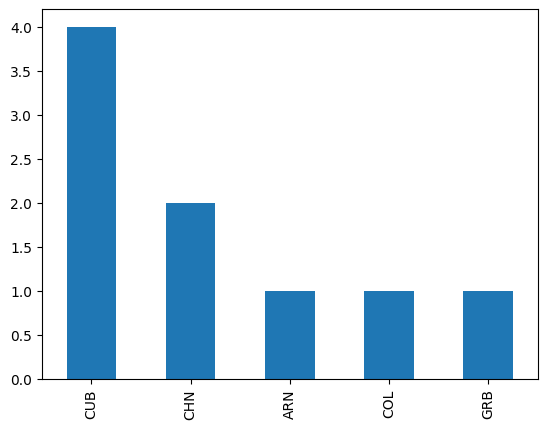

In [17]:
# Campos: ['Nacionalidad', 'Número Trámite', 'Fecha Inicio Vigencia', 'Fecha Fin Vigencia', 'Tipo Tiempo Otorgado', 'Tiempo Otorgado']

df_4_f = df_4.groupby(by=['Nacionalidad']).agg({ 'Número Trámite': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='count', ascending=False) \
             .head(5)

df_4_f.plot.bar(legend=False, xlabel='')


### 3.5 Se define como regla que, al obtener un carnet nuevo(CE, CPP), los anteriores deben ser anulados.

In [18]:
# Extracción
df_5 = pd.read_excel('./data/A5.xlsx')

<Axes: >

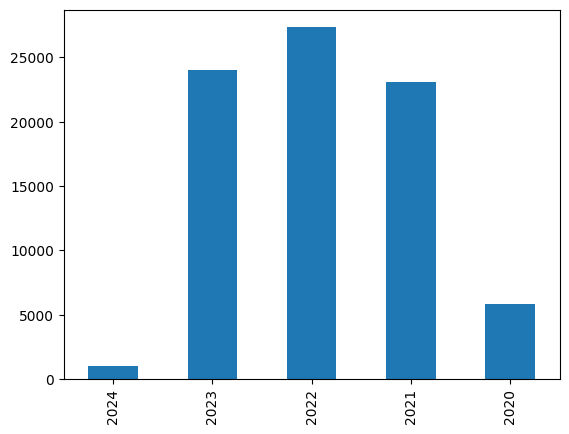

In [23]:
# Campos: ['Número Trámite', 'Número Carnet', 'Fecha Inicio Vigencia', 'Fecha Fin Vigencia']

df_5['año_vigencia'] = df_5['Fecha Inicio Vigencia'].dt.year

df_1_2 = df_5.groupby(by=['año_vigencia']).agg({ 'Número Trámite': [np.ma.count] }) \
             .droplevel(level=0, axis=1) \
             .sort_values(by='año_vigencia', ascending=False) \
             .head(5)

df_1_2.plot.bar(legend=False, xlabel='')

In [9]:
list = [2, 4, 5, 7, 9]

list_mayus = [i for i in list if i % 2 == 0]

list_mayus

[2, 4]